In [ ]:
#Sentiment analysis on smartphone review dataset
import pandas as pd

try:
    data = pd.read_excel("/content/Dataset.xlsx")
    print("Dataset loaded successfully!")

except FileNotFoundError:
    print("Error: Dataset file not found.")

except Exception as e:
    print("An error occurred:", e)

Dataset loaded successfully!


In [ ]:
#create a dataframe
df = pd.DataFrame(data)
print("Original DataFrame:")
print(df.head())

Original DataFrame:
   No.  actual_price  rating  \
0    1        7700.0       2   
1    2       30700.0       3   
2    3       21000.0       1   
3    4       23200.0       2   
4    5       23200.0       5   

                                         review_text    brand  \
0  This rating is not for the product.... Its for...    Apple   
1  The product is usable and matches the basic de...    Nokia   
2                                           dont buy   realme   
3                                Phone  is  superb    Samsung   
4         My data cable started to getting damage!!!  Samsung   

                                 cleaned_review_text sentiment  
0  rating product seller delivered product scratc...  Negative  
1  hanging issue network dropping issue needed re...   Neutral  
2                                           dont buy  Negative  
3                                       phone superb  Negative  
4                  data cable started getting damage  Positive  


In [ ]:
from pandas.io.api import read_excel
#file Handling

#read an excel file
data = pd.read_excel("/content/Dataset.xlsx")
data.head()

#write a file
data.to_excel(
    "/content/Sentiment_Results.xlsx",
    index=False
)

print("Data saved successfully!")

Data saved successfully!


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   No.                  500 non-null    int64  
 1   actual_price         498 non-null    float64
 2   rating               500 non-null    int64  
 3   review_text          500 non-null    object 
 4   brand                500 non-null    object 
 5   cleaned_review_text  497 non-null    object 
 6   sentiment            500 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 27.5+ KB


In [ ]:
data.head()

,No.,actual_price,rating,review_text,brand,cleaned_review_text,sentiment
0,1,7700.0,2,This rating is not for the product.... Its for...,Apple,rating product seller delivered product scratc...,Negative
1,2,30700.0,3,The product is usable and matches the basic de...,Nokia,hanging issue network dropping issue needed re...,Neutral
2,3,21000.0,1,dont buy,realme,dont buy,Negative
3,4,23200.0,2,Phone is superb,Samsung,phone superb,Negative
4,5,23200.0,5,My data cable started to getting damage!!!,Samsung,data cable started getting damage,Positive


In [ ]:
print(data["brand"].value_counts())
print(data["sentiment"].value_counts())

brand
Apple           104
Samsung          64
OnePlus          51
Redmi            49
Oppo             44
Nokia            42
realme           38
Google Pixel     37
Vivo             36
Motorola         35
Name: count, dtype: int64
sentiment
Positive    209
Negative    191
Neutral     100
Name: count, dtype: int64


In [ ]:
#check the missing values\
print(data.isnull().sum())

# Remove duplicate records
data = data.drop_duplicates()

#check for any duplicate values
print("Duplicates:", data.duplicated().sum())

# Remove rows with missing review text
data = data.dropna(subset=["review_text", "sentiment"])

print("Rows:", data.shape[0])
print("Columns:", data.shape[1])



No.                    0
actual_price           2
rating                 0
review_text            0
brand                  0
cleaned_review_text    3
sentiment              0
dtype: int64
Duplicates: 0
Rows: 500
Columns: 7


In [ ]:
#fill the null values

data["actual_price"] = data["actual_price"].fillna(
    data["actual_price"].median()
)

print(data.isnull().sum())

print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

No.                    0
actual_price           0
rating                 0
review_text            0
brand                  0
cleaned_review_text    3
sentiment              0
dtype: int64
Rows: 500
Columns: 7


In [ ]:
try:
    df["rating"] = pd.to_numeric(
        df["rating"],
        errors="raise"
    )

    print("Rating data is valid.")

except ValueError:
    print("Error: Invalid rating value found.")

except Exception as e:
    print("Unexpected error:", e)

Rating data is valid.


In [ ]:
try:
    sentiments = df["sentiment"]
    print("Sentiment column found.")

except KeyError:
    print("Error: Sentiment column does not exist.")

Sentiment column found.


In [ ]:
#Count reviews by sentiment
sentiment_count = df["sentiment"].value_counts()

print("Sentiment Count")
print(sentiment_count)

#Filter positive reviews
positive_reviews = df[df["sentiment"] == "Positive"]

#Filter negative reviews
negative_reviews = df[df["sentiment"] == "Negative"]

#Filter neutral reviews
neutral_reviews = df[df["sentiment"] == "Neutral"]

#Analyze sentiment according to rating
sentiment_rating = pd.crosstab(
    df["rating"],
    df["sentiment"]
)
print("")
print(sentiment_rating)

#Find average rating for each sentiment
avg_rating_sentiment = df.groupby("sentiment")["rating"].mean()

print("")
print(avg_rating_sentiment)

Sentiment Count
sentiment
Positive    209
Negative    191
Neutral     100
Name: count, dtype: int64

sentiment  Negative  Neutral  Positive
rating                                
1               151        0         0
2                40        0         0
3                 0      100         0
4                 0        0        39
5                 0        0       170

sentiment
Negative    1.209424
Neutral     3.000000
Positive    4.813397
Name: rating, dtype: float64


In [ ]:
samsung_reviews = df[df["brand"] == "Samsung"]

samsung_positive = df[
    (df["brand"] == "Samsung") &
    (df["rating"] >= 4)
]

samsung = df[df["brand"] == "Samsung"]

print("Total Samsung reviews:", len(samsung))
print("Average Samsung rating:", samsung["rating"].mean())
print("Average Samsung price:", samsung["actual_price"].mean())
samsung_sentiment = samsung.groupby("sentiment").size()

print(samsung_sentiment)
print(df["brand"].unique())
print(df["brand"].value_counts())

Total Samsung reviews: 64
Average Samsung rating: 3.046875
Average Samsung price: 35179.25
sentiment
Negative    25
Neutral     13
Positive    26
dtype: int64
['Apple' 'Nokia' 'realme' 'Samsung' 'OnePlus' 'Oppo' 'Redmi' 'Motorola'
 'Vivo' 'Google Pixel']
brand
Apple           104
Samsung          64
OnePlus          51
Redmi            49
Oppo             44
Nokia            42
realme           38
Google Pixel     37
Vivo             36
Motorola         35
Name: count, dtype: int64


In [ ]:
apple_df = df[df["brand"] == "Apple"]

# Sentiment distribution for Apple
apple_sentiment = apple_df["sentiment"].value_counts()

print(apple_sentiment)

apple_analysis = pd.crosstab(
    apple_df["rating"],
    apple_df["sentiment"]
)

print(apple_analysis)

avg_rating = apple_df.groupby("sentiment")["rating"].mean()

print(avg_rating)

apple_df["review_length"] = apple_df["review_text"].astype(str).str.len()

review_length = apple_df.groupby("sentiment")["review_length"].mean()

print(review_length)

sentiment
Negative    48
Positive    46
Neutral     10
Name: count, dtype: int64
sentiment  Negative  Neutral  Positive
rating                                
1                37        0         0
2                11        0         0
3                 0       10         0
4                 0        0         7
5                 0        0        39
sentiment
Negative    1.229167
Neutral     3.000000
Positive    4.847826
Name: rating, dtype: float64
sentiment
Negative    240.708333
Neutral      56.800000
Positive     75.326087
Name: review_length, dtype: float64


/tmp/ipykernel_2601/802301114.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple_df["review_length"] = apple_df["review_text"].astype(str).str.len()


In [ ]:
#Which brands have the highest average rating?
brand_analysis = df.groupby("brand")["rating"].mean().sort_values(ascending=False)

print("")
print(brand_analysis)

#Which brands have the most reviews?
brand_reviews = df["brand"].value_counts()
print("")
print(brand_reviews)


brand
Oppo            3.522727
Motorola        3.200000
Vivo            3.194444
realme          3.184211
Redmi           3.061224
Samsung         3.046875
OnePlus         3.000000
Apple           3.000000
Nokia           2.880952
Google Pixel    2.783784
Name: rating, dtype: float64

brand
Apple           104
Samsung          64
OnePlus          51
Redmi            49
Oppo             44
Nokia            42
realme           38
Google Pixel     37
Vivo             36
Motorola         35
Name: count, dtype: int64


In [ ]:
def preprocess_text(text):

    try:
        text = text.lower()

        text = re.sub(
            r"http\S+|www\S+",
            "",
            text
        )

        text = re.sub(
            r"[^a-zA-Z\s]",
            "",
            text
        )

        tokens = word_tokenize(text)

        tokens = [
            word for word in tokens
            if word not in stop_words
        ]

        tokens = [
            lemmatizer.lemmatize(word)
            for word in tokens
        ]

        return " ".join(tokens)

    except Exception as e:
        print("Text processing error:", e)
        return ""

In [ ]:
try:
    total = len(df)

    positive = len(df[df["sentiment"] == "Positive"])
    negative = len(df[df["sentiment"] == "Negative"])
    neutral = len(df[df["sentiment"] == "Neutral"])

    print("Positive probability:", positive / total)
    print("Negative probability:", negative / total)
    print("Neutral probability:", neutral / total)

except ZeroDivisionError:
    print("Error: Dataset contains no records.")

Positive probability: 0.418
Negative probability: 0.382
Neutral probability: 0.2


In [ ]:
brand_df = df[df["brand"] == "Apple"]

total = len(brand_df)

positive = len(brand_df[brand_df["sentiment"] == "Positive"])
negative = len(brand_df[brand_df["sentiment"] == "Negative"])
neutral = len(brand_df[brand_df["sentiment"] == "Neutral"])

print("Total Apple reviews:", total)

print("P(Positive):", positive / total)
print("P(Negative):", negative / total)
print("P(Neutral):", neutral / total)

Total Apple reviews: 104
P(Positive): 0.4423076923076923
P(Negative): 0.46153846153846156
P(Neutral): 0.09615384615384616


In [ ]:
sample_df = df.sample(n=50, random_state=42)
print("Sample size:", len(sample_df))

sample_sentiment = sample_df["sentiment"].value_counts()
print(sample_sentiment)

sample_probability = sample_df["sentiment"].value_counts(normalize=True)
print(sample_probability)

full_probability = df["sentiment"].value_counts(normalize=True)

print("Full dataset:")
print(full_probability)

print("\nSample:")
print(sample_probability)

Sample size: 50
sentiment
Positive    28
Negative    12
Neutral     10
Name: count, dtype: int64
sentiment
Positive    0.56
Negative    0.24
Neutral     0.20
Name: proportion, dtype: float64
Full dataset:
sentiment
Positive    0.418
Negative    0.382
Neutral     0.200
Name: proportion, dtype: float64

Sample:
sentiment
Positive    0.56
Negative    0.24
Neutral     0.20
Name: proportion, dtype: float64


In [ ]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["rating"], df["sentiment"])

print(table)

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis.")
    print("There is a significant relationship between rating and sentiment.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no significant relationship between rating and sentiment.")

sentiment  Negative  Neutral  Positive
rating                                
1               151        0         0
2                40        0         0
3                 0      100         0
4                 0        0        39
5                 0        0       170
Chi-Square Statistic: 999.9999999999999
P-value: 1.4932281660407321e-210
Reject the null hypothesis.
There is a significant relationship between rating and sentiment.


In [ ]:
#custom module
%%writefile sentiment_analysis.py

def calculate_percentage(count, total):
    """Calculate percentage."""

    if total == 0:
        return 0

    return (count / total) * 100


def sentiment_percentage(data):
    """Calculate percentage of each sentiment."""

    total = len(data)

    positive = len(data[data["sentiment"] == "Positive"])
    negative = len(data[data["sentiment"] == "Negative"])
    neutral = len(data[data["sentiment"] == "Neutral"])

    return {
        "Positive": round(calculate_percentage(positive, total), 2),
        "Negative": round(calculate_percentage(negative, total), 2),
        "Neutral": round(calculate_percentage(neutral, total), 2)
    }


Writing sentiment_analysis.py


In [ ]:
import sentiment_analysis as sa

samsung = data[data["brand"] == "Samsung"]
check = sa.sentiment_percentage(samsung)

print(check)

{'Positive': 40.62, 'Negative': 39.06, 'Neutral': 20.31}


In [ ]:
import numpy as np

# Select Samsung products
samsung = data[data["brand"] == "Samsung"]

# Convert columns into NumPy arrays
ratings = np.array(samsung["rating"].dropna())
prices = np.array(samsung["actual_price"].dropna())

# Calculate statistics
avg_rating = np.mean(ratings)
highest_price = np.max(prices)
lowest_price = np.min(prices)

print("Samsung Analysis")
print("Average Rating:", avg_rating)
print("Highest Rating:", np.max(ratings))
print("Lowest Rating:", np.min(ratings))
print("\nHighest Price:", highest_price)
print("Lowest Price:", lowest_price)

Samsung Analysis
Average Rating: 3.046875
Highest Rating: 5
Lowest Rating: 1

Highest Price: 125600.0
Lowest Price: 6995.0


In [ ]:
print(samsung["sentiment"].value_counts())
percentage = (
    samsung["sentiment"].value_counts(normalize=True) * 100
)

print(percentage.round(2))

sentiment
Positive    26
Negative    25
Neutral     13
Name: count, dtype: int64
sentiment
Positive    40.62
Negative    39.06
Neutral     20.31
Name: proportion, dtype: float64


In [ ]:
from scipy import stats

# Select Samsung ratings
samsung_ratings = data[
    data["brand"] == "Samsung"
]["rating"].dropna()

# Descriptive statistics
result = stats.describe(samsung_ratings)

print("Number of observations:", result.nobs)
print("Minimum:", result.minmax[0])
print("Maximum:", result.minmax[1])
print("Mean:", result.mean)
print("Variance:", result.variance)


samsung_ratings = data[
    data["brand"] == "Samsung"
]["rating"].dropna()



Number of observations: 64
Minimum: 1
Maximum: 5
Mean: 3.046875
Variance: 2.616815476190476


In [ ]:
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
import nltk
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)


text = "The students are studying in colleges and playing games!"

print(clean_text(text))

student studying college playing game


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
data["cleaned_review_text"] = data["review_text"].apply(clean_text)
print(data[["review_text", "cleaned_review_text"]].head(5))

                                         review_text  \
0  This rating is not for the product.... Its for...   
1  The product is usable and matches the basic de...   
2                                           dont buy   
3                                Phone  is  superb     
4         My data cable started to getting damage!!!   

                                 cleaned_review_text  
0  rating product seller delivered product scratc...  
1             product usable match basic description  
2                                           dont buy  
3                                       phone superb  
4                  data cable started getting damage  


In [ ]:
import nltk

nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

review = "Amazing phone with excellent camera, fast performance, and great battery life!"

score = sia.polarity_scores(review)

print("Review:", review)
print("Negative:", score["neg"])
print("Neutral:", score["neu"])
print("Positive:", score["pos"])
print("Compound:", score["compound"])

# Final sentiment
if score["compound"] >= 0.05:
    sentiment = "Positive"
elif score["compound"] <= -0.05:
    sentiment = "Negative"
else:
    sentiment = "Neutral"

print("Final Sentiment:", sentiment)

Review: Amazing phone with excellent camera, fast performance, and great battery life!
Negative: 0.0
Neutral: 0.402
Positive: 0.598
Compound: 0.9168
Final Sentiment: Positive


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
# TF-IDF Vectorization

from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Convert cleaned text into numerical vectors
X = vectorizer.fit_transform(data["cleaned_review_text"])

print("TF-IDF Vectorization completed successfully!")
print("Shape of vectorized data:", X.shape)

TF-IDF Vectorization completed successfully!
Shape of vectorized data: (500, 3848)


In [ ]:
# Get feature names

features = vectorizer.get_feature_names_out()

print("Number of features:", len(features))

print("\nFirst 20 features:")
print(features[:20])

Number of features: 3848

First 20 features:
['aaple' 'aaple bad' 'ability' 'ability due' 'able' 'able activate'
 'able recieve' 'able return' 'able unlock' 'able use' 'abruptly'
 'abruptly annoying' 'absolute' 'absolute joy' 'absolutely'
 'absolutely perfect' 'acceptable' 'acceptable room' 'accepting'
 'accepting bad']


In [ ]:
# Display TF-IDF vectors

tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=features
)

print(tfidf_df.head())

   aaple  aaple bad  ability  ability due  able  able activate  able recieve  \
0    0.0        0.0      0.0          0.0   0.0            0.0           0.0   
1    0.0        0.0      0.0          0.0   0.0            0.0           0.0   
2    0.0        0.0      0.0          0.0   0.0            0.0           0.0   
3    0.0        0.0      0.0          0.0   0.0            0.0           0.0   
4    0.0        0.0      0.0          0.0   0.0            0.0           0.0   

   able return  able unlock  able use  ...  yesterday  yesterday place  \
0          0.0          0.0       0.0  ...        0.0              0.0   
1          0.0          0.0       0.0  ...        0.0              0.0   
2          0.0          0.0       0.0  ...        0.0              0.0   
3          0.0          0.0       0.0  ...        0.0              0.0   
4          0.0          0.0       0.0  ...        0.0              0.0   

   yesterday voice  yet  yet start  youre  youre vested  zero  zero noise 

Top 3 Brands with Highest Positive Reviews:
Apple : 46 reviews ( 22.01 %)
Samsung : 26 reviews ( 12.44 %)
Oppo : 23 reviews ( 11.0 %)


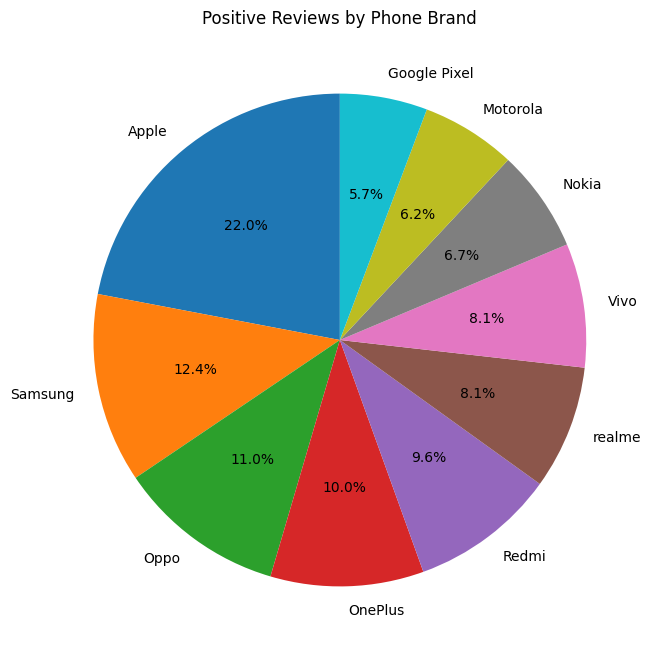

In [ ]:
import matplotlib.pyplot as plt

# Select only positive reviews
positive_reviews = data[data["sentiment"] == "Positive"]

# Count positive reviews for each brand
positive_by_brand = positive_reviews["brand"].value_counts()
top_3_brands = positive_by_brand.head(3)

total_positive = len(positive_reviews)

print("Top 3 Brands with Highest Positive Reviews:")

for brand, count in top_3_brands.items():
    percentage = (count / total_positive) * 100
    print(
        brand,
        ":", count,
        "reviews (",
        round(percentage, 2),
        "%)"
    )
# Pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    positive_by_brand.values,
    labels=positive_by_brand.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Positive Reviews by Phone Brand")
plt.show()

Top 3 Brands with Highest Positive Reviews:
Apple : 48 reviews ( 25.13 %)
Samsung : 25 reviews ( 13.09 %)
OnePlus : 23 reviews ( 12.04 %)


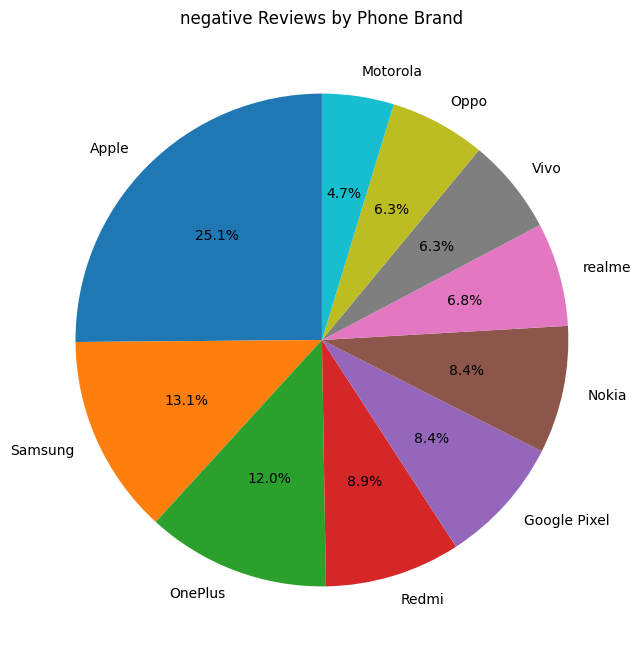

In [ ]:
import matplotlib.pyplot as plt

# Select only positive reviews
negative_reviews = data[data["sentiment"] == "Negative"]

# Count positive reviews for each brand
negative_by_brand = negative_reviews["brand"].value_counts()
top_3_brands = negative_by_brand.head(3)

total_negative = len(negative_reviews)

print("Top 3 Brands with Highest Negative Reviews:")

for brand, count in top_3_brands.items():
    percentage = (count / total_negative) * 100
    print(
        brand,
        ":", count,
        "reviews (",
        round(percentage, 2),
        "%)"
    )

# Pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    negative_by_brand.values,
    labels=negative_by_brand.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("negative Reviews by Phone Brand")
plt.show()

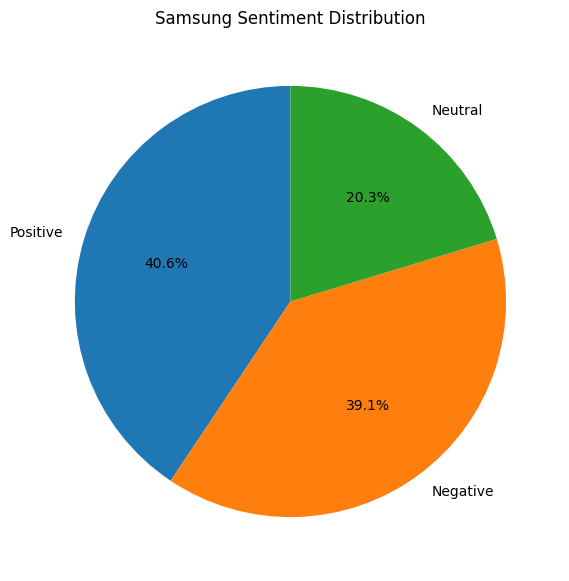

In [ ]:
# Select Samsung reviews
samsung = data[data["brand"] == "Samsung"]

# Count Samsung sentiments
samsung_sentiment = samsung["sentiment"].value_counts()

# Pie chart
plt.figure(figsize=(7, 7))

plt.pie(
    samsung_sentiment.values,
    labels=samsung_sentiment.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Samsung Sentiment Distribution")
plt.show()

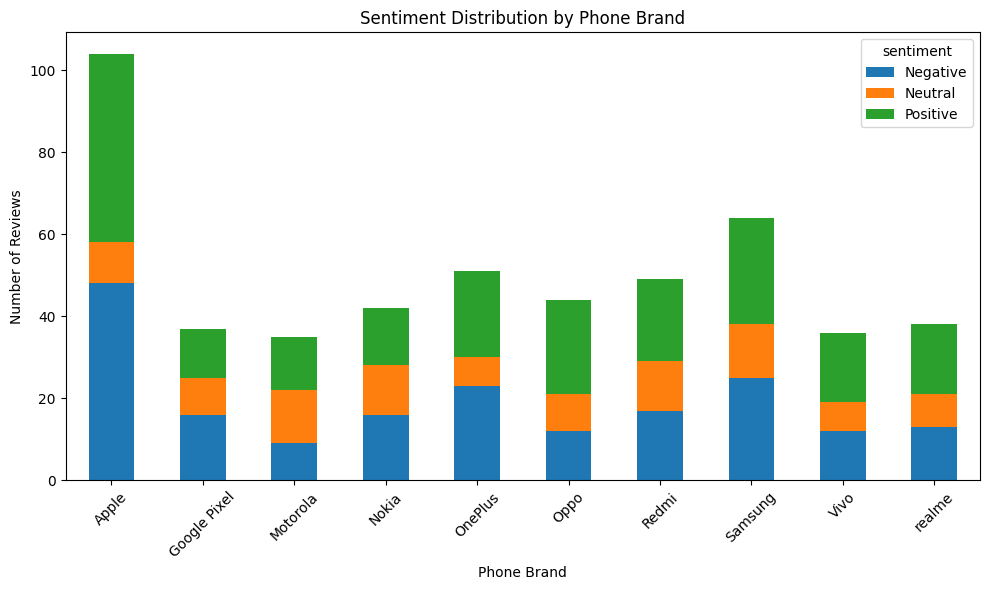

In [ ]:
sentiment_by_brand = pd.crosstab(
    data["brand"],
    data["sentiment"]
)

sentiment_by_brand.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Sentiment Distribution by Phone Brand")
plt.xlabel("Phone Brand")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

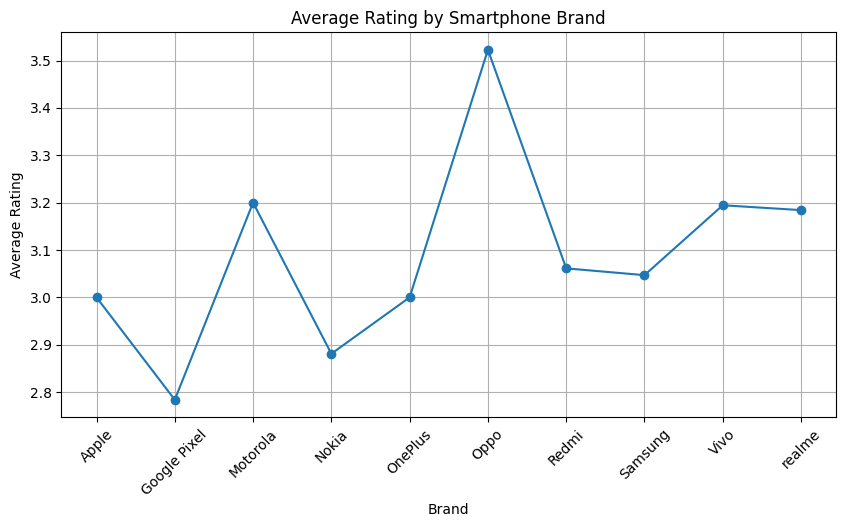

In [ ]:
import matplotlib.pyplot as plt

average_rating = df.groupby("brand")["rating"].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    average_rating.index,
    average_rating.values,
    marker="o"
)

plt.title("Average Rating by Smartphone Brand")
plt.xlabel("Brand")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
import sqlite3

conn = sqlite3.connect("sentiment_analysis.db")
cursor = conn.cursor()

In [ ]:
print("Database created successfully!")

cursor.execute("""
CREATE TABLE IF NOT EXISTS reviews (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    brand TEXT,
    rating INTEGER,
    review_text TEXT,
    sentiment TEXT
)
""")

conn.commit()

print("Reviews table created successfully!")


Database created successfully!
Reviews table created successfully!


In [ ]:
five_reviews = data.head(5)
for _, row in five_reviews.iterrows():

    cursor.execute("""
    INSERT INTO reviews
    (brand, rating, review_text, sentiment)
    VALUES (?, ?, ?, ?)
    """, (
        row["brand"],
        row["rating"],
        row["review_text"],
        row["sentiment"]
    ))

conn.commit()

print("5 reviews added successfully!")

5 reviews added successfully!


In [ ]:
cursor.execute("SELECT * FROM reviews")

for row in cursor.fetchall():
    print(row)

(2, 'Nokia', 4, 'The product is usable and matches the basic description.', 'Neutral')
(3, 'realme', 1, 'dont buy', 'Negative')
(4, 'Samsung', 2, '  Phone  is  superb  ', 'Negative')
(5, 'Samsung', 5, 'My data cable started to getting damage!!!', 'Positive')
(6, 'Apple', 2, 'This rating is not for the product.... Its for the seller... Who has delivered the product with scratches on the back panel.....', 'Negative')
(7, 'Nokia', 3, 'The product is usable and matches the basic description.', 'Neutral')
(8, 'realme', 1, 'dont buy', 'Negative')
(9, 'Samsung', 2, '  Phone  is  superb  ', 'Negative')
(10, 'Samsung', 5, 'My data cable started to getting damage!!!', 'Positive')


In [ ]:
cursor.execute("""
UPDATE reviews
SET rating = ?
WHERE id = ?
""", (4, 2))

conn.commit()

print("Review updated successfully!")

Review updated successfully!


In [ ]:
cursor.execute("""
DELETE FROM reviews
WHERE id = ?
""", (1,))

conn.commit()

print("Review deleted successfully!")

Review deleted successfully!


In [ ]:
cursor.execute("SELECT * FROM reviews")

for row in cursor.fetchall():
    print(row)

(2, 'Nokia', 4, 'The product is usable and matches the basic description.', 'Neutral')
(3, 'realme', 1, 'dont buy', 'Negative')
(4, 'Samsung', 2, '  Phone  is  superb  ', 'Negative')
(5, 'Samsung', 5, 'My data cable started to getting damage!!!', 'Positive')
(6, 'Apple', 2, 'This rating is not for the product.... Its for the seller... Who has delivered the product with scratches on the back panel.....', 'Negative')
(7, 'Nokia', 3, 'The product is usable and matches the basic description.', 'Neutral')
(8, 'realme', 1, 'dont buy', 'Negative')
(9, 'Samsung', 2, '  Phone  is  superb  ', 'Negative')
(10, 'Samsung', 5, 'My data cable started to getting damage!!!', 'Positive')


In [ ]:
# MACHINE LEARNING - SENTIMENT ANALYSIS

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
df = pd.read_excel("Dataset.xlsx")

# Remove rows where review text or sentiment is missing
df = df.dropna(subset=["review_text", "sentiment"])

# Input (X) and Target (y)
X = df["review_text"]
y = df["sentiment"]

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Convert text into numerical features using TF-IDF
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Create Machine Learning model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train_tfidf, y_train)

# Predict sentiment for test data
y_pred = model.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("===== MACHINE LEARNING RESULTS =====")
print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("Accuracy:", accuracy)

# Classification report
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\n===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, y_pred))

# Test the model with a new review
new_review = ["The phone has excellent camera quality and battery life"]

new_review_tfidf = vectorizer.transform(new_review)

prediction = model.predict(new_review_tfidf)

print("\n===== NEW REVIEW PREDICTION =====")
print("Review:", new_review[0])
print("Predicted Sentiment:", prediction[0])


===== MACHINE LEARNING RESULTS =====
Training records: 400
Testing records: 100
Accuracy: 0.88

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    Negative       0.84      0.84      0.84        38
     Neutral       1.00      1.00      1.00        20
    Positive       0.86      0.86      0.86        42

    accuracy                           0.88       100
   macro avg       0.90      0.90      0.90       100
weighted avg       0.88      0.88      0.88       100


===== CONFUSION MATRIX =====
[[32  0  6]
 [ 0 20  0]
 [ 6  0 36]]

===== NEW REVIEW PREDICTION =====
Review: The phone has excellent camera quality and battery life
Predicted Sentiment: Positive
